>># ***MASTERCARD CREDIT CARD FRAUD DETECTION SYSTEM*** 
###

### 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.utils import resample

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

### 2. LOAD DATASET

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (6848, 31)


In [4]:
print("\nFirst 5 Rows:\n")
df.head()


First 5 Rows:



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,60.0,-1.098620,1.420504,-0.113481,0.221558,1.234752,-1.031955,0.595491,-0.589895,-0.132169,...,1.146030,-0.777371,1.558789,-1.530461,1.629642,-0.372676,-0.242699,-1.890010,17.298425,0
1,66.0,-0.454795,-1.039807,-0.607646,-0.137311,0.957792,0.207603,0.307677,-1.095519,-0.880754,...,0.891304,0.004230,0.618886,1.638360,0.381310,0.311653,-1.518911,-2.630730,35.262469,0
2,126.0,0.388376,-0.094824,-0.514783,0.243530,-0.060404,1.127780,0.086111,-0.746923,0.990166,...,-0.297376,-0.246383,0.986377,-0.711973,-1.542803,-0.160631,-0.484174,-0.966246,72.761898,0
3,138.0,-0.175378,0.491506,-0.009289,0.306981,1.813408,-0.342879,0.278349,-0.509213,-0.846360,...,-2.386930,-0.495878,1.097300,-1.565648,-3.007632,0.571179,0.243657,-1.090208,4.933191,0
4,155.0,-0.985540,-0.969744,0.110535,-0.626315,0.494064,-2.854627,-0.856852,-1.126054,-0.256341,...,-0.005560,1.178513,-1.373403,0.519902,1.868818,0.419706,0.276582,0.008556,118.933445,0


In [5]:
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6848 entries, 0 to 6847
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    6848 non-null   float64
 1   V1      6848 non-null   float64
 2   V2      6848 non-null   float64
 3   V3      6848 non-null   float64
 4   V4      6848 non-null   float64
 5   V5      6848 non-null   float64
 6   V6      6848 non-null   float64
 7   V7      6848 non-null   float64
 8   V8      6848 non-null   float64
 9   V9      6848 non-null   float64
 10  V10     6848 non-null   float64
 11  V11     6848 non-null   float64
 12  V12     6848 non-null   float64
 13  V13     6848 non-null   float64
 14  V14     6848 non-null   float64
 15  V15     6848 non-null   float64
 16  V16     6848 non-null   float64
 17  V17     6848 non-null   float64
 18  V18     6848 non-null   float64
 19  V19     6848 non-null   float64
 20  V20     6848 non-null   float64
 21  V21     6848 non-null

In [6]:
print("\nDataset Description:\n")
df.describe()


Dataset Description:



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,...,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000,6848.000000
mean,86929.955754,0.167683,0.123220,0.125745,0.151832,0.159815,0.157972,0.152062,0.160840,0.161933,...,0.151866,0.161841,0.143278,0.133713,0.135751,0.168401,0.151013,0.125450,39.763077,0.071846
std,50217.909476,1.211320,1.194406,1.185826,1.194600,1.213864,1.188153,1.172841,1.194937,1.194486,...,1.209911,1.201414,1.199918,1.172127,1.218518,1.198799,1.182022,1.193666,71.868091,0.258251
min,60.000000,-4.544647,-3.627208,-4.013840,-4.465604,-3.773820,-4.171308,-3.940008,-3.245580,-3.655087,...,-3.346238,-3.782616,-5.946572,-4.066894,-4.295391,-4.489591,-3.744778,-4.566793,0.500000,0.000000
25%,43118.750000,-0.613364,-0.647773,-0.648803,-0.636169,-0.624738,-0.603232,-0.614844,-0.611290,-0.616655,...,-0.647790,-0.615234,-0.620635,-0.638342,-0.647424,-0.582763,-0.621204,-0.653364,10.518350,0.000000
50%,87145.000000,0.090303,0.051082,0.079274,0.067944,0.075035,0.095435,0.085438,0.088264,0.074396,...,0.072648,0.073325,0.065435,0.049126,0.051183,0.091650,0.083775,0.040026,21.435121,0.000000
75%,131386.750000,0.853348,0.785841,0.782848,0.822080,0.810021,0.799506,0.820219,0.804730,0.832266,...,0.835817,0.838688,0.808575,0.797574,0.791127,0.800255,0.804983,0.789627,43.548061,0.000000
max,172760.000000,6.790537,6.964136,6.841966,7.145652,7.053455,7.378116,6.869985,7.086945,7.311010,...,7.315634,7.123566,7.718071,6.510343,7.231230,8.383751,7.588544,6.881373,3236.860093,1.000000


### 3. DATA CLEANING

In [7]:
print("\nMissing Values:\n")
df.isnull().sum()


Missing Values:



Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# Remove duplicates

df.drop_duplicates(inplace=True)

In [9]:
print("\nShape after removing duplicates:", df.shape)


Shape after removing duplicates: (6848, 31)


### 4. FEATURE ENGINEERING

In [10]:
# Log transformation for amount

df["LogAmount"] = np.log1p(df["Amount"])

In [11]:
# Transaction hour extraction

df["TransactionHour"] = df["Time"] // 3600

In [12]:
# Day period categorization

def categorize_hour(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["DayPeriod"] = df["TransactionHour"].apply(categorize_hour)

In [13]:
# Convert categorical to dummy variables

df = pd.get_dummies(df, columns=["DayPeriod"], drop_first=True)

### 5. EXPLORATORY DATA ANALYSIS

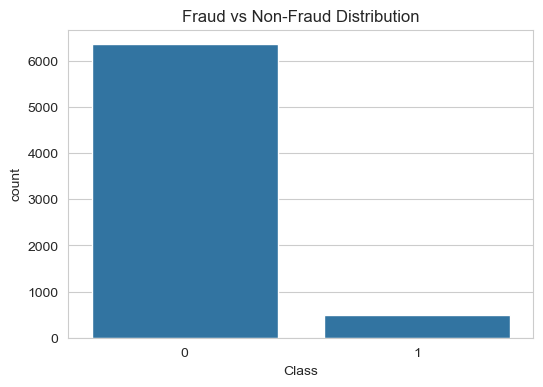

In [14]:
# Fraud vs Non-Fraud distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

In [15]:
fraud_ratio = df["Class"].value_counts(normalize=True)
print("\nFraud Ratio:")
print(fraud_ratio)


Fraud Ratio:
Class
0    0.928154
1    0.071846
Name: proportion, dtype: float64


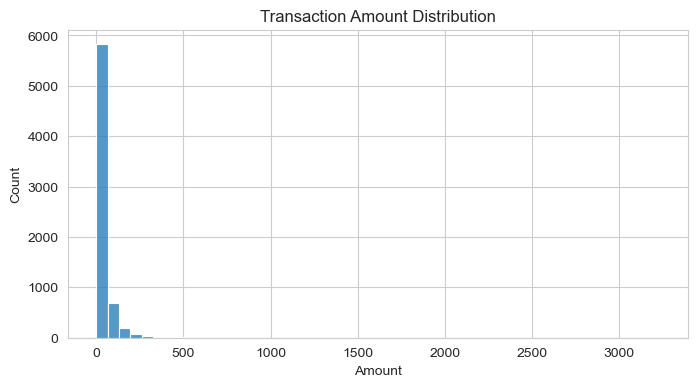

In [16]:
# Transaction Amount Distribution

plt.figure(figsize=(8,4))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

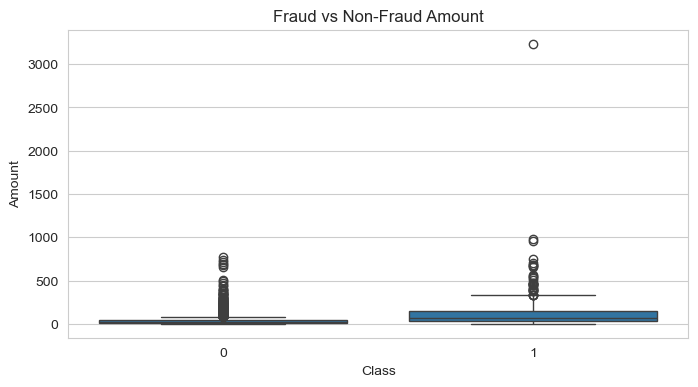

In [17]:
# Fraud Amount Distribution

plt.figure(figsize=(8,4))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Fraud vs Non-Fraud Amount")
plt.show()

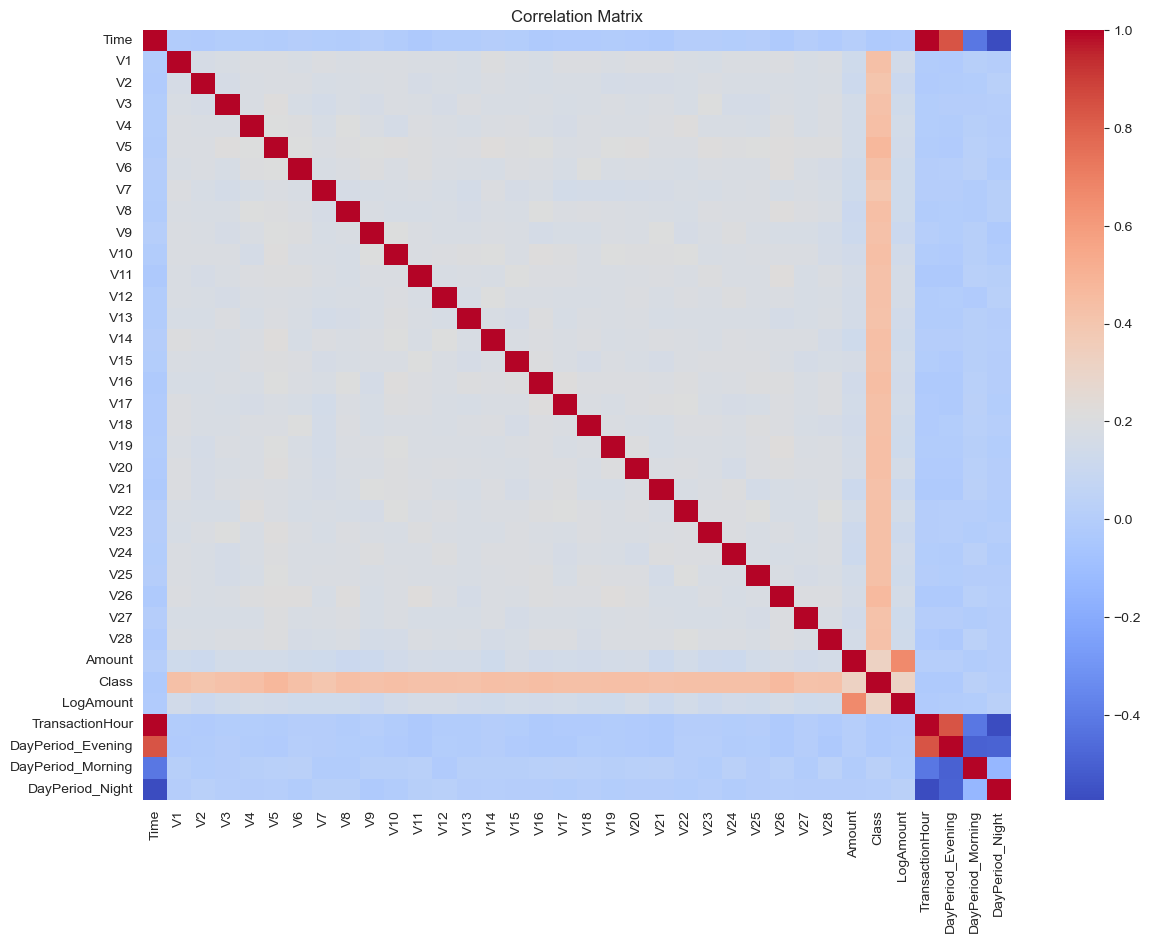

In [18]:
# Correlation Heatmap

plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### 6. HANDLE CLASS IMBALANCE

In [19]:
fraud = df[df.Class == 1]
normal = df[df.Class == 0]

In [20]:
print("\nFraud Transactions:", len(fraud))


Fraud Transactions: 492


In [21]:
print("Normal Transactions:", len(normal))

Normal Transactions: 6356


In [22]:
# Oversampling fraud cases

fraud_oversampled = resample(
    fraud,
    replace=True,
    n_samples=len(normal),
    random_state=42
)

In [23]:
balanced_df = pd.concat([normal, fraud_oversampled])

In [24]:
print("\nBalanced Dataset Shape:", balanced_df.shape)


Balanced Dataset Shape: (12712, 36)


### 7. FEATURE SELECTION

In [25]:
X = balanced_df.drop("Class", axis=1)
y = balanced_df["Class"]

### 8. DATA SPLITTING

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [27]:
print("\nTraining Shape:", X_train.shape)


Training Shape: (9534, 35)


In [28]:
print("Testing Shape:", X_test.shape)

Testing Shape: (3178, 35)


### 9. FEATURE SCALING

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 10. MODEL TRAINING

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=50),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50)
}

results = {}

In [31]:
for name, model in models.items():

    print("\nTraining:", name)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    }


Training: Logistic Regression

Training: Random Forest

Training: Gradient Boosting


### 11. MODEL COMPARISON

In [32]:
results_df = pd.DataFrame(results).T

In [33]:
print("\nModel Performance Comparison:")
print(results_df)


Model Performance Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression       1.0        1.0     1.0       1.0      1.0
Random Forest             1.0        1.0     1.0       1.0      1.0
Gradient Boosting         1.0        1.0     1.0       1.0      1.0


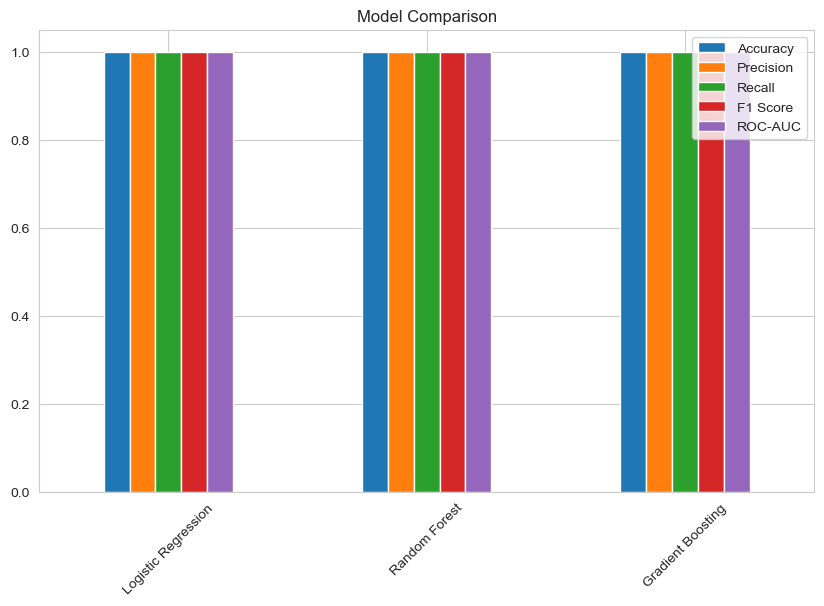

In [34]:
# Visualization

results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()

### 12. BEST MODEL SELECTION

In [35]:
best_model_name = results_df["ROC-AUC"].idxmax()
best_model = models[best_model_name]

In [36]:
print("\nBest Model:", best_model_name)


Best Model: Logistic Regression


### 13. CONFUSION MATRIX

In [37]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

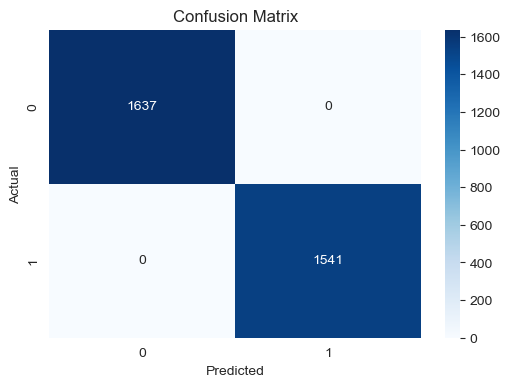

In [38]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1637
           1       1.00      1.00      1.00      1541

    accuracy                           1.00      3178
   macro avg       1.00      1.00      1.00      3178
weighted avg       1.00      1.00      1.00      3178



### 14. ROC CURVE

In [40]:
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

In [41]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

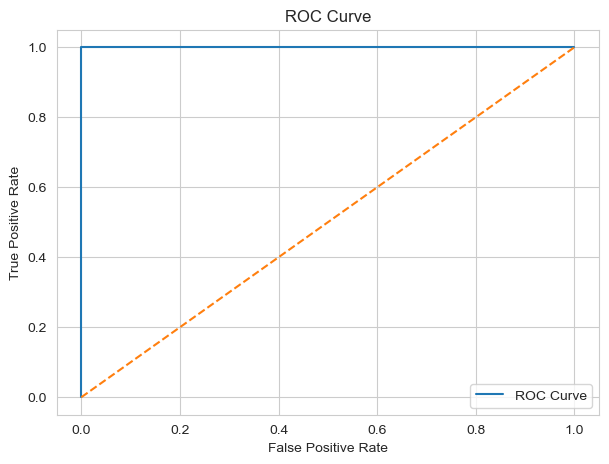

In [42]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### 15. FEATURE IMPORTANCE

In [43]:
if best_model_name == "Random Forest":

    importance = best_model.feature_importances_

    features = X.columns

    feat_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10,7))
    sns.barplot(x="Importance", y="Feature", data=feat_df.head(20))
    plt.title("Top Important Features")
    plt.show()

### 16. CROSS VALIDATION

In [44]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [45]:
print("\nCross Validation ROC-AUC:", cv_scores.mean())


Cross Validation ROC-AUC: 1.0


### 17. FRAUD PROBABILITY SCORING

In [46]:
test_sample = X_test.iloc[0].values.reshape(1, -1)
test_sample_scaled = scaler.transform(test_sample)

In [47]:
fraud_prob = best_model.predict_proba(test_sample_scaled)[0][1]

In [48]:
print("\nSample Transaction Fraud Probability:", round(fraud_prob,4))


Sample Transaction Fraud Probability: 0.0


### 18. FRAUD RISK SEGMENTATION

In [49]:
def risk_level(prob):

    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

balanced_df["FraudProbability"] = best_model.predict_proba(
    scaler.transform(X)
)[:,1]

In [50]:
balanced_df["RiskLevel"] = balanced_df["FraudProbability"].apply(risk_level)

In [51]:
print("\nRisk Distribution:")
print(balanced_df["RiskLevel"].value_counts())


Risk Distribution:
RiskLevel
Low Risk     6356
High Risk    6356
Name: count, dtype: int64


### 19. BUSINESS INSIGHTS DATA

In [52]:
fraud_transactions = balanced_df[balanced_df["Class"] == 1]

In [53]:
avg_fraud_amount = fraud_transactions["Amount"].mean()

In [54]:
print("\nAverage Fraud Amount:", avg_fraud_amount)


Average Fraud Amount: 121.97648006665813


### 20. SAVE OUTPUT FILES

In [55]:
balanced_df.to_csv("Fraud_Risk_Predictions.csv", index=False)

In [56]:
results_df.to_csv("Model_Performance_Comparison.csv")

In [57]:
print("\nOutputs Saved Successfully")


Outputs Saved Successfully


# ~~~~~~~~~~~~ END OF FRAUD DETECTION SYSTEM ~~~~~~~~~~~~~